In [1]:
# Name : Ashita Gupta
# Roll No. : 2022BCY0008
# Project for FUNDAMENTAL OF DATA SCIENCE
# Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Loading the data
# Dataset source URL : https://www.kaggle.com/datasets/jancsg/cybersecurity-suspicious-web-threat-interactions
df = pd.read_csv('CloudWatch_Traffic_Web_Attack.csv')

In [3]:
print("Columns and their data types:")
print(df.dtypes)

Columns and their data types:
bytes_in                int64
bytes_out               int64
creation_time          object
end_time               object
src_ip                 object
src_ip_country_code    object
protocol               object
response.code           int64
dst_port                int64
dst_ip                 object
rule_names             object
observation_name       object
source.meta            object
source.name            object
time                   object
detection_types        object
dtype: object


In [4]:
# Data Preprocessing
# Converting time-related columns to datetime
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['time'] = pd.to_datetime(df['time'])

In [5]:
# Handling missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
bytes_in               0
bytes_out              0
creation_time          0
end_time               0
src_ip                 0
src_ip_country_code    0
protocol               0
response.code          0
dst_port               0
dst_ip                 0
rule_names             0
observation_name       0
source.meta            0
source.name            0
time                   0
detection_types        0
dtype: int64


In [6]:
# Encoding categorical variables
le = LabelEncoder()
categorical_columns = ['src_ip', 'src_ip_country_code', 'protocol', 'dst_ip', 'rule_names', 'observation_name', 'source.meta', 'source.name', 'detection_types']
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [7]:
# Exploratory Data Analysis (EDA)
# Basic statistics
print(df.describe())

           bytes_in     bytes_out      src_ip  src_ip_country_code  protocol  \
count  2.820000e+02  2.820000e+02  282.000000           282.000000     282.0   
mean   1.199390e+06  8.455429e+04    7.907801             3.804965       0.0   
std    4.149312e+06  2.549279e+05    6.437104             2.083893       0.0   
min    4.000000e+01  4.400000e+01    0.000000             0.000000       0.0   
25%    5.381500e+03  1.114200e+04    4.000000             2.000000       0.0   
50%    1.318200e+04  1.379950e+04    7.000000             4.000000       0.0   
75%    3.083300e+04  2.627950e+04   11.000000             6.000000       0.0   
max    2.520779e+07  1.561220e+06   27.000000             6.000000       0.0   

       response.code  dst_port  dst_ip  rule_names  observation_name  \
count          282.0     282.0   282.0       282.0             282.0   
mean           200.0     443.0     0.0         0.0               0.0   
std              0.0       0.0     0.0         0.0             

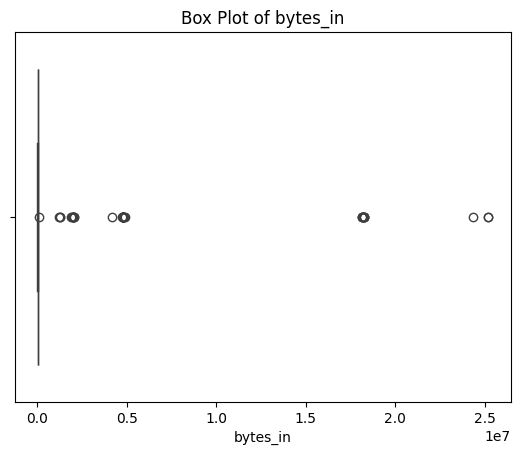

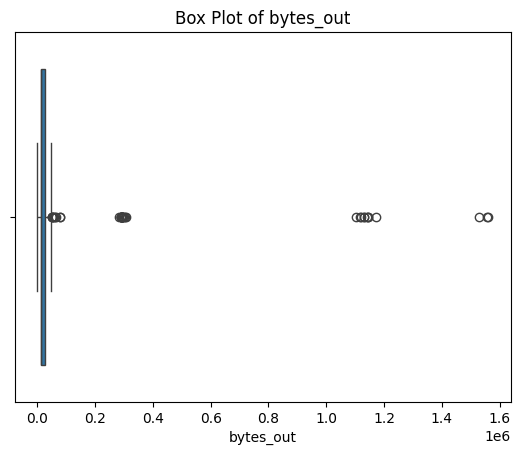

In [8]:
# Box Plot
for col in ['bytes_in', 'bytes_out']:
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

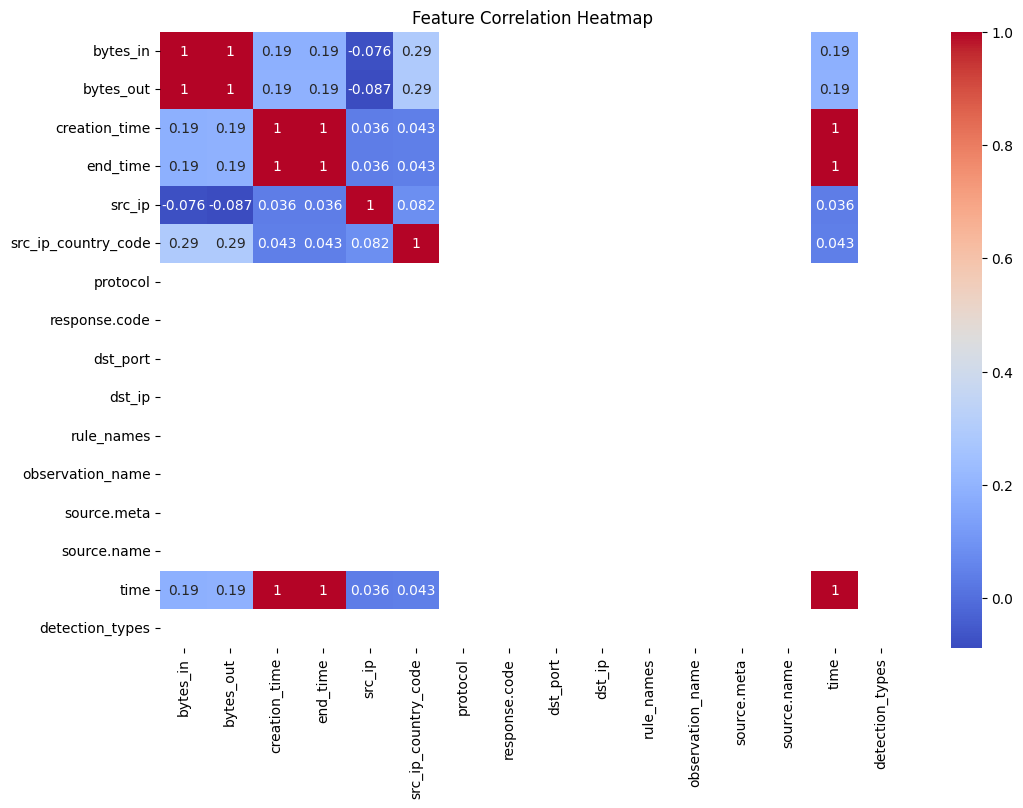

In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [10]:
# Feature Engineering
# Creating new features
df['duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()
df['hour_of_day'] = df['creation_time'].dt.hour

In [11]:
# Standardization
scaler = StandardScaler()
numerical_columns = ['bytes_in', 'bytes_out', 'duration', 'response.code', 'dst_port']
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [12]:
# Anomaly Detection
# Isolation Forest
isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly'] = isolation_forest.fit_predict(df[['bytes_in', 'bytes_out', 'duration']])

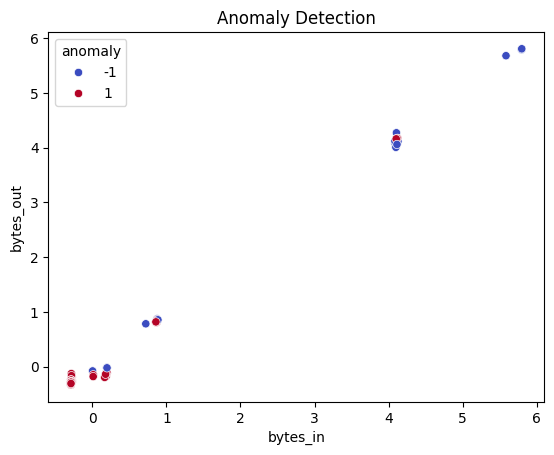

In [13]:
# Visualizing Anomalies
sns.scatterplot(data=df, x='bytes_in', y='bytes_out', hue='anomaly', palette='coolwarm')
plt.title('Anomaly Detection')
plt.show()

In [14]:
# Classification
# Preparing data
X = df.drop(columns=['anomaly', 'creation_time', 'end_time', 'time'])
y = (df['anomaly'] == -1).astype(int)  # 1 for anomalies, 0 for normal

In [15]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
# Defining models
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

Training RandomForest...

RandomForest - Accuracy: 0.9529
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        80
           1       1.00      0.20      0.33         5

    accuracy                           0.95        85
   macro avg       0.98      0.60      0.65        85
weighted avg       0.96      0.95      0.94        85

ROC AUC Score: 0.8875


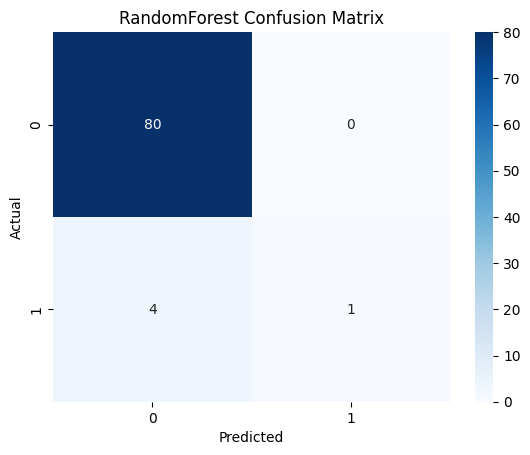

Training LogisticRegression...

LogisticRegression - Accuracy: 0.9529
              precision    recall  f1-score   support

           0       0.96      0.99      0.98        80
           1       0.67      0.40      0.50         5

    accuracy                           0.95        85
   macro avg       0.82      0.69      0.74        85
weighted avg       0.95      0.95      0.95        85

ROC AUC Score: 0.8075


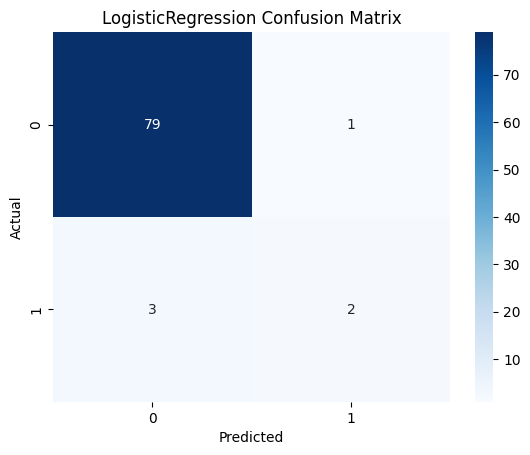

Training SVM...

SVM - Accuracy: 0.9529
              precision    recall  f1-score   support

           0       0.96      0.99      0.98        80
           1       0.67      0.40      0.50         5

    accuracy                           0.95        85
   macro avg       0.82      0.69      0.74        85
weighted avg       0.95      0.95      0.95        85

ROC AUC Score: 0.8400


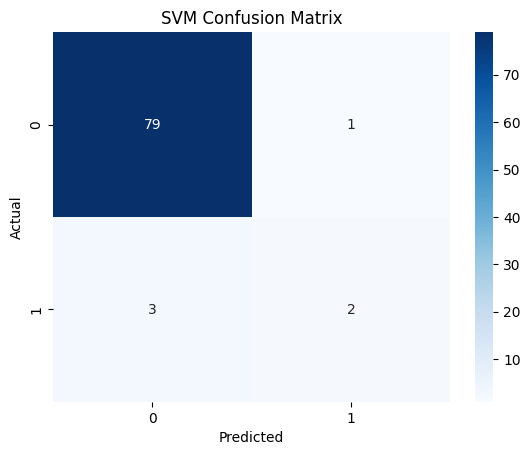

Training KNN...

KNN - Accuracy: 0.9529
              precision    recall  f1-score   support

           0       0.96      0.99      0.98        80
           1       0.67      0.40      0.50         5

    accuracy                           0.95        85
   macro avg       0.82      0.69      0.74        85
weighted avg       0.95      0.95      0.95        85

ROC AUC Score: 0.7750


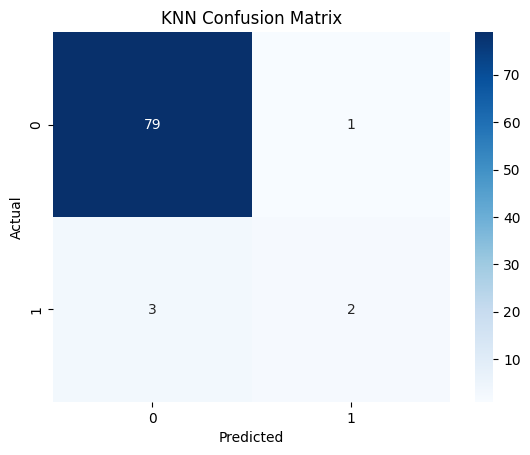

Training DecisionTree...

DecisionTree - Accuracy: 0.9765
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        80
           1       1.00      0.60      0.75         5

    accuracy                           0.98        85
   macro avg       0.99      0.80      0.87        85
weighted avg       0.98      0.98      0.97        85

ROC AUC Score: 0.8000


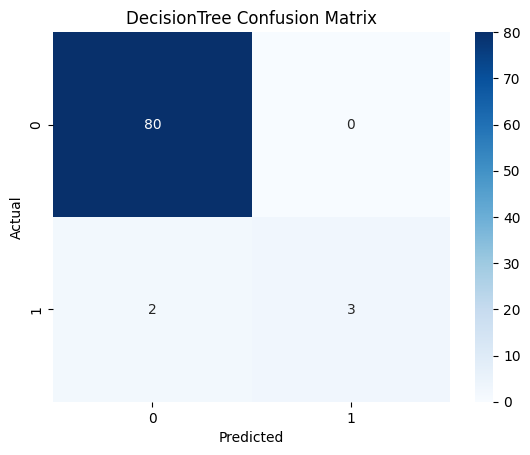

In [17]:
# Training and evaluating models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    print(f"\n{name} - Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    
    if y_pred_prob is not None:
        print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


In [19]:
# Cross-validation
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} - Cross-validation scores: {cv_scores}")
    print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")

RandomForest - Cross-validation scores: [0.95       0.95       0.97435897 0.97435897 0.97435897]
Mean CV Accuracy: 0.9646
LogisticRegression - Cross-validation scores: [0.975      0.975      0.97435897 0.97435897 0.97435897]
Mean CV Accuracy: 0.9746
SVM - Cross-validation scores: [0.975      0.975      0.97435897 0.97435897 0.97435897]
Mean CV Accuracy: 0.9746
KNN - Cross-validation scores: [0.975      0.975      0.97435897 0.97435897 0.97435897]
Mean CV Accuracy: 0.9746
DecisionTree - Cross-validation scores: [0.975      0.95       0.97435897 1.         0.94871795]
Mean CV Accuracy: 0.9696
